In [4]:
%pip install pillow


Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("All libraries working!")

All libraries working!


# 1st Project :Implementation of Gaussian Elimination Algorithm for Solving Linear Systems


In [12]:
import numpy as np


# Function for Gaussian Elimination
def gaussian_elimination(A, b):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    # Check matrix dimensions
    if A.ndim != 2:
        raise ValueError("Coefficient matrix must be 2-dimensional.")

    if A.shape[0] != A.shape[1]:
        raise ValueError("Coefficient matrix must be square.")

    if len(b) != A.shape[0]:
        raise ValueError("Invalid matrix dimensions.")

    if not np.all(np.isfinite(A)) or not np.all(np.isfinite(b)):
        raise ValueError("Matrix contains invalid values.")

    n = len(b)

    # Form augmented matrix
    aug = np.column_stack((A, b))

    print("Augmented Matrix:")
    print(aug)

    # Forward Elimination with Partial Pivoting
    for i in range(n):

        # Partial Pivoting
        pivot_row = i + np.argmax(np.abs(aug[i:, i]))

        if abs(aug[pivot_row, i]) < 1e-10:

            # Check for inconsistent system
            for r in range(i, n):
                if (np.all(np.abs(aug[r, :n]) < 1e-10)
                        and abs(aug[r, n]) > 1e-10):
                    raise ValueError(
                        "System has no solution."
                    )

            raise ValueError(
                "Singular matrix: system does not have a unique solution."
            )

        # Swap rows
        if pivot_row != i:
            aug[[i, pivot_row]] = aug[[pivot_row, i]]

        # Eliminate elements below pivot
        for j in range(i + 1, n):
            factor = aug[j, i] / aug[i, i]
            aug[j] = aug[j] - factor * aug[i]

    print("\nMatrix after Forward Elimination:")
    print(aug)

    return aug


# Separate function for Back Substitution
def back_substitution(aug):
    n = aug.shape[0]
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):

        if abs(aug[i, i]) < 1e-10:
            raise ValueError("Zero pivot encountered during back substitution.")

        sum_value = np.sum(
            aug[i, i + 1:n] * x[i + 1:n]
        )

        x[i] = (aug[i, -1] - sum_value) / aug[i, i]

    return x


# Complete solver function
def solve_system(A, b):
    A_original = np.array(A, dtype=float)
    b_original = np.array(b, dtype=float)

    upper_matrix = gaussian_elimination(A, b)

    solution = back_substitution(upper_matrix)

    return A_original, b_original, upper_matrix, solution


# =========================================================
# SYSTEM 1
# =========================================================

A1 = [
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
]

b1 = [8, -11, -3]

print("===================================")
print("SYSTEM 1")
print("===================================")

print("Coefficient Matrix:")
print(np.array(A1))

print("\nRHS Vector:")
print(np.array(b1))

try:
    A1_original, b1_original, U1, x1 = solve_system(A1, b1)

    print("\nSolution using Back Substitution:")
    for i in range(len(x1)):
        print("x" + str(i + 1), "=", x1[i])

    # Verification
    verification1 = np.dot(A1_original, x1)

    print("\nVerification:")
    print("A × x =", verification1)
    print("Original b =", b1_original)

    if np.allclose(verification1, b1_original):
        print("Verification Successful.")

except ValueError as e:
    print("Error:", e)


# =========================================================
# SYSTEM 2
# =========================================================

A2 = [
    [1, 1, 1],
    [2, -1, 1],
    [1, 2, -1]
]

b2 = [6, 3, 2]

print("\n\n===================================")
print("SYSTEM 2")
print("===================================")

print("Coefficient Matrix:")
print(np.array(A2))

print("\nRHS Vector:")
print(np.array(b2))

try:
    A2_original, b2_original, U2, x2 = solve_system(A2, b2)

    print("\nSolution using Back Substitution:")
    for i in range(len(x2)):
        print("x" + str(i + 1), "=", x2[i])

    # Verification
    verification2 = np.dot(A2_original, x2)

    print("\nVerification:")
    print("A × x =", verification2)
    print("Original b =", b2_original)

    if np.allclose(verification2, b2_original):
        print("Verification Successful.")

except ValueError as e:
    print("Error:", e)

SYSTEM 1
Coefficient Matrix:
[[ 2  1 -1]
 [-3 -1  2]
 [-2  1  2]]

RHS Vector:
[  8 -11  -3]
Augmented Matrix:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]

Matrix after Forward Elimination:
[[ -3.          -1.           2.         -11.        ]
 [  0.           1.66666667   0.66666667   4.33333333]
 [  0.           0.           0.2         -0.2       ]]

Solution using Back Substitution:
x1 = 2.0
x2 = 3.0000000000000004
x3 = -0.9999999999999999

Verification:
A × x = [  8. -11.  -3.]
Original b = [  8. -11.  -3.]
Verification Successful.


SYSTEM 2
Coefficient Matrix:
[[ 1  1  1]
 [ 2 -1  1]
 [ 1  2 -1]]

RHS Vector:
[6 3 2]
Augmented Matrix:
[[ 1.  1.  1.  6.]
 [ 2. -1.  1.  3.]
 [ 1.  2. -1.  2.]]

Matrix after Forward Elimination:
[[ 2.  -1.   1.   3. ]
 [ 0.   2.5 -1.5  0.5]
 [ 0.   0.   1.4  4.2]]

Solution using Back Substitution:
x1 = 1.0
x2 = 2.0000000000000004
x3 = 3.0000000000000004

Verification:
A × x = [6. 3. 2.]
Original b = [6. 3. 2.]
Verificati

# 2nd Project :Implementation of Data Augmentation using Affine Transformation

Enter translation in x direction:  50
Enter translation in y direction:  30
Enter rotation angle:  45
Enter scaling factor x:  1.5
Enter scaling factor y:  1.5
Enter shearing factor x:  0.3
Enter shearing factor y:  0


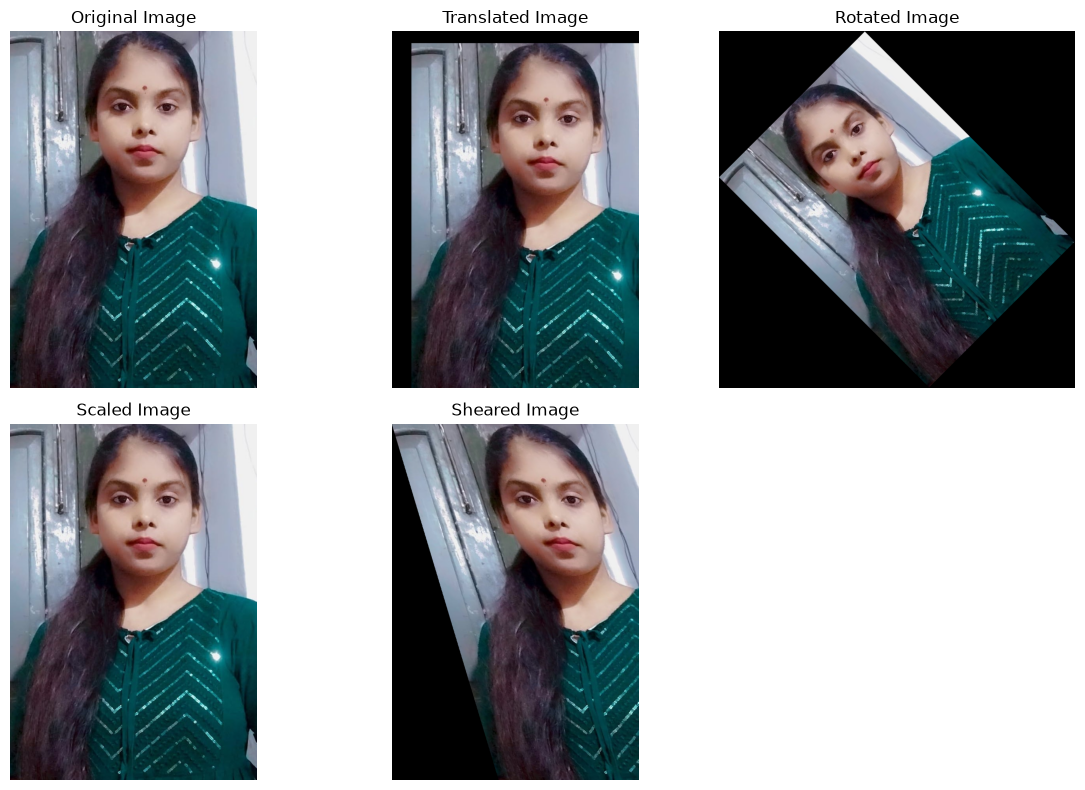


Translation Matrix:
[[ 1.  0. 50.]
 [ 0.  1. 30.]
 [ 0.  0.  1.]]

Rotation Matrix:
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Scaling Matrix:
[[1.5 0.  0. ]
 [0.  1.5 0. ]
 [0.  0.  1. ]]

Shearing Matrix:
[[1.  0.3 0. ]
 [0.  1.  0. ]
 [0.  0.  1. ]]


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Read input image
img = Image.open("priya_img.jpg")

# Convert image to array
image_array = np.array(img)

# ---------------- TRANSLATION ----------------
def translation(image, tx, ty):
    matrix = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

    result = image.transform(
        image.size,
        Image.Transform.AFFINE,
        (1, 0, -tx, 0, 1, -ty)
    )

    return result, matrix


# ---------------- ROTATION ----------------
def rotation(image, angle):
    rad = np.radians(angle)

    matrix = np.array([
        [np.cos(rad), -np.sin(rad), 0],
        [np.sin(rad),  np.cos(rad), 0],
        [0, 0, 1]
    ])

    result = image.rotate(angle, expand=True)

    return result, matrix


# ---------------- SCALING ----------------
def scaling(image, sx, sy):
    matrix = np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

    result = image.resize(
        (int(image.width * sx),
         int(image.height * sy))
    )

    return result, matrix


# ---------------- SHEARING ----------------
def shearing(image, shx, shy):
    matrix = np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ])

    result = image.transform(
        image.size,
        Image.Transform.AFFINE,
        (1, -shx, 0, -shy, 1, 0)
    )

    return result, matrix


# -------- USER PARAMETERS --------
tx = float(input("Enter translation in x direction: "))
ty = float(input("Enter translation in y direction: "))

angle = float(input("Enter rotation angle: "))

sx = float(input("Enter scaling factor x: "))
sy = float(input("Enter scaling factor y: "))

shx = float(input("Enter shearing factor x: "))
shy = float(input("Enter shearing factor y: "))


# Apply transformations
translated, T = translation(img, tx, ty)
rotated, R = rotation(img, angle)
scaled, S = scaling(img, sx, sy)
sheared, H = shearing(img, shx, shy)


# Display images
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(translated)
plt.title("Translated Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sheared)
plt.title("Sheared Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# Save augmented images
translated.save("translated.jpg")
rotated.save("rotated.jpg")
scaled.save("scaled.jpg")
sheared.save("sheared.jpg")


# Display transformation matrices
print("\nTranslation Matrix:")
print(T)

print("\nRotation Matrix:")
print(R)

print("\nScaling Matrix:")
print(S)

print("\nShearing Matrix:")
print(H)